# Project - Progress Report #3 - Evaluating Model Performance

Serena Reese, Amiran Fields and Tatum Beaugh

2025 FALL SEMESTER - Introduction to Data Science (CS-4330-D10)

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
try:
    df = pd.read_csv('/content/drive/MyDrive/CS/AI Cybersecurity/CIS_datasets/AggregateDataSet/scada_resolved_agg_30s.csv', sep=",", encoding='utf-8', engine="python")
except UnicodeDecodeError:
        print("UnicodeDecodeError")

OUTPUT_DIR = '/content/drive/MyDrive/CS/AI Cybersecurity/CIS_datasets/AggregateDataSet'

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352236 entries, 0 to 352235
Data columns (total 21 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   bucket                     352236 non-null  object 
 1   system_id                  352236 non-null  object 
 2   protocol                   352236 non-null  object 
 3   avg_size                   352236 non-null  float64
 4   source_total_packets       352236 non-null  int64  
 5   destination_total_packets  352236 non-null  int64  
 6   min_size                   352236 non-null  int64  
 7   max_size                   352236 non-null  int64  
 8   num_connections            352236 non-null  int64  
 9   source_ip                  351941 non-null  object 
 10  source_port                351872 non-null  float64
 11  source_mac                 352236 non-null  object 
 12  destination_ip             351941 non-null  object 
 13  destination_port           35

Although not the most efficient method, we can train a linear regression model to predict num_attacks from numerical and categorical fields.

# Task 1

## Identify two attributes in the consumable usage dataset and develop a linear regression model
> Use the identified attributes and sklearn.linear_model.LinearRegression

In [4]:
target = "num_attacks"

numeric_features = [
    "avg_size", "source_total_packets", "destination_total_packets",
    "min_size", "max_size", "num_connections", "source_port", "destination_port"
]

categorical_features = ["protocol", "bucket", "source_asset", "destination_asset", "attack_types"]

This is a complex dataset, so it's useful to use multiple features in a pipeline-like linear regression model. We'll have to clean the data first, though.

## Basic cleaning - dropping rows missing the target, or all numeric features

In [5]:
df_model = df.dropna(subset=[target])  # keep rows with target
df_model = df_model.dropna(subset=numeric_features, how="all")  # require at least some numeric data here guys

## Fill numeric NaNs with median, categorical with placeholder

In [6]:
df_model[numeric_features] = df_model[numeric_features].fillna(df_model[numeric_features].median())
df_model[categorical_features] = df_model[categorical_features].fillna("missing")

X = df_model[numeric_features + categorical_features]
y = df_model[target].astype(float)

## Train/test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

## Preprocessing pipelines for scaling

In [8]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
], remainder="drop")

## Full pipeline using LinearRegression

In [9]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

## Fit the model

In [10]:
pipeline.fit(X_train, y_train)
model_simple = pipeline #for later comparison

## Measure the performance of the model and make sure that the model performance is high

In [11]:
# Predicting and evaluating
y_pred = pipeline.predict(X_test)
print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.9418962074052161
MSE: 98001.47070778516
MAE: 51.45382198984696


It seems like the model has a very high R2, which makes us suspicious of its results. According to this, the model seems to explain most variance in num_attacks. MSE and MAE are large in absolute terms though, so those error magnitudes depend on the scale and distribution of num_attacks, whether this is acceptable depends on our goals.

## Cross-validation to check results

In [12]:
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring="r2")
print("CV R2 mean:", np.mean(cv_scores), "std:", np.std(cv_scores))

CV R2 mean: -24.930455947562436 std: 47.37131464273927


The cross-validated results show the model performs far worse than a constant mean predictor on some folds, so our large negative mean and huge variance means one or more of these issues are present:
1. Data leakage or preprocessing outside our CV
2. Severe target skew/outliers
3. Folds with very different distributions
4. Time-series ordering used with the random CV
5. Inappropriate model for the count data

## Inspect the coefficients for approximate mapping

In [13]:
# Remember that after preprocessing, feature order is numeric_features then onehot categories.
reg = pipeline.named_steps["regressor"]
if hasattr(reg, "coef_"):
    coefs = reg.coef_
    print("Number of coefficients:", len(coefs))

Number of coefficients: 409


Our pipeline here expanded categorical variables into many one-hot columns.

## Draw a plot using matplotlib to show the observed and predicted values

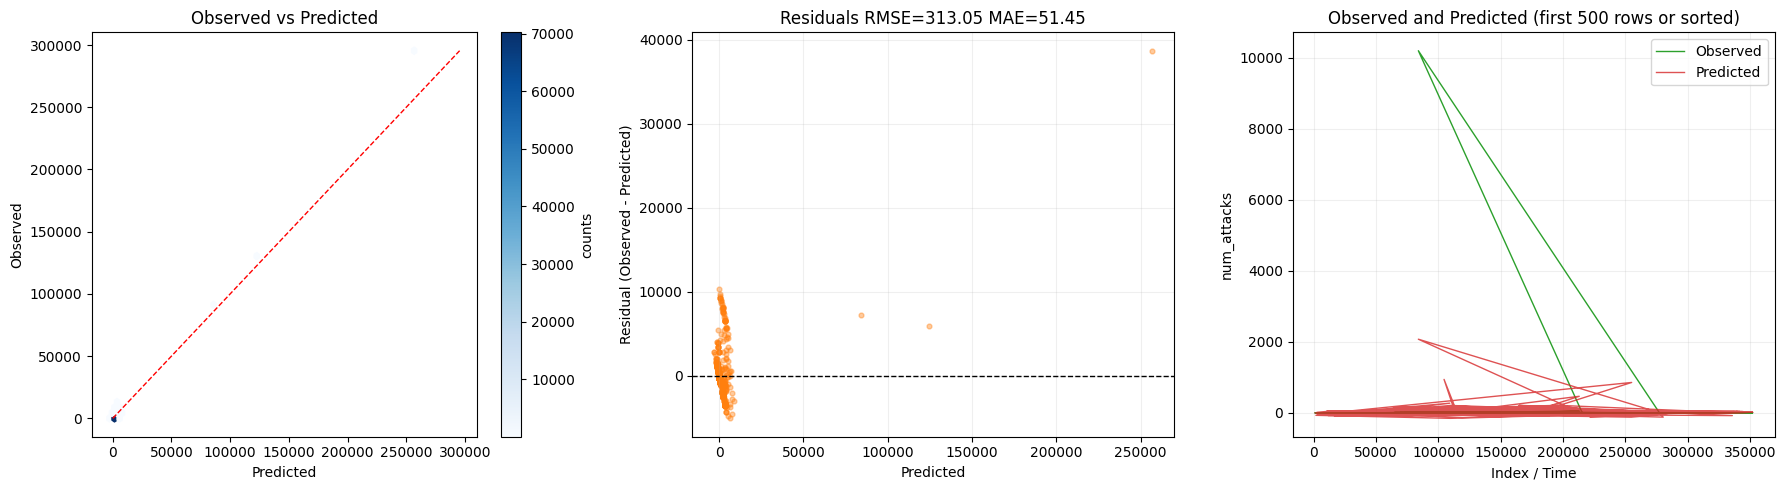

In [14]:
# y_test and y_pred should already be available (numpy arrays or pandas Series)
# If they are pandas Series keep the index for the time plot, otherwise an integer index will be used.
y_true = np.asarray(y_test).ravel()
y_pred = np.asarray(y_pred).ravel()

# Optional: if target was transformed (log1p), inverse transform here
# y_true = np.expm1(y_true)
# y_pred = np.expm1(y_pred)

# Metrics
residuals = y_true - y_pred
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

# Create figure with three panels
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Observed vs Predicted scatter with density shading
ax = axes[0]
hb = ax.hexbin(y_pred, y_true, gridsize=60, cmap="Blues", mincnt=1)
ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()],
        color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Predicted")
ax.set_ylabel("Observed")
ax.set_title("Observed vs Predicted")
cbar = fig.colorbar(hb, ax=ax)
cbar.set_label("counts")

# Panel 2: Residuals vs Predicted
ax = axes[1]
ax.scatter(y_pred, residuals, alpha=0.4, s=12, color="#ff7f0e")
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Predicted")
ax.set_ylabel("Residual (Observed - Predicted)")
ax.set_title(f"Residuals RMSE={rmse:.2f} MAE={mae:.2f}")
ax.grid(alpha=0.2)

# Panel 3: Time series slice or sorted comparison
ax = axes[2]
# Use index if y_test is a Series, otherwise use integer index
if isinstance(y_test, (pd.Series, pd.DataFrame)):
    idx = y_test.index[:500]
    obs = y_true[:500]
    pred = y_pred[:500]
    ax.plot(idx, obs, label="Observed", color="#2ca02c", linewidth=1)
    ax.plot(idx, pred, label="Predicted", color="#d62728", linewidth=1, alpha=0.8)
    ax.set_xlabel("Index / Time")
else:
    # If no time index, show sorted values to visualize fit across range
    order = np.argsort(y_true)
    ax.plot(np.arange(len(y_true))[:500], y_true[order][:500], label="Observed (sorted)", color="#2ca02c", linewidth=1)
    ax.plot(np.arange(len(y_pred))[:500], y_pred[order][:500], label="Predicted (sorted)", color="#d62728", linewidth=1, alpha=0.8)
    ax.set_xlabel("Sorted sample index")
ax.set_ylabel("num_attacks")
ax.set_title("Observed and Predicted (first 500 rows or sorted)")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
fig.savefig(OUTPUT_DIR + "/observed_predicted_residuals_sorted", dpi=150, bbox_inches='tight')
plt.show()

Most points cluster near zero with a tight cloud, but some values lie far from the line, meaning the model fits the bulk of the data while struggling on high counts. Residuals concentrate near zero, but show large positive and negative outliers. Heteroscedasticity and a few influential points drive error metrics. Spikes in the observed series aren't fully captured by predictions, explaining the previous large RMSE, despite the overall high R2.

## Report loss functions:
1. mean squared error
2. root mean squared error
3. mean absolute error

In [15]:
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
print(f"MSE={mse:.2f}, RMSE={rmse:.2f}, MAE={mae:.2f}")

MSE=98001.47, RMSE=313.05, MAE=51.45


Here's an average squared error, sensitive to outliers. The typical magniutde of an error is the same units as num_attacks, and the average absolute error, which is robust to outliers and relative to RMSE, perform not so well.

# Task 2

## Identify more than two attributes in the consumable usage dataset and develop a multiple linear regression model using the identified attributes
> Use sklearn.linear_model.LinearRegression

In [16]:
target = "num_attacks"
numeric_features = [
    "avg_size", "source_total_packets", "destination_total_packets",
    "min_size", "max_size", "num_connections", "source_port", "destination_port"
]
categorical_features = ["protocol", "bucket", "attack_types", "source_asset", "destination_asset"]

## Basic cleaning and preparation

In [17]:
df_model = df.copy()
df_model = df_model.dropna(subset=[target])  # require target

# Fill numeric NaNs with median
df_model[numeric_features] = df_model[numeric_features].fillna(df_model[numeric_features].median())

# Fill categorical NaNs with placeholder
df_model[categorical_features] = df_model[categorical_features].fillna("missing").astype(str)

# Optional: reduce cardinality for attack_types if extremely high
# df_model['attack_types'] = df_model['attack_types'].apply(lambda x: x if df_model['attack_types'].value_counts().get(x,0) > 50 else 'other')

X = df_model[numeric_features + categorical_features]
y = df_model[target].astype(float)

## Train/test split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)

## Preprocessing pipelines

In [19]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
], remainder="drop")

# --- 5. Full pipeline with LinearRegression
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

## Fit the model

In [20]:
pipeline.fit(X_train, y_train)
model_more = pipeline #for later comparison

## Measure the performance of the model and make sure that the model performance is high

In [21]:
# Predict and evaluate on the test set
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE = {mse:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"MAE = {mae:.2f}")
print(f"R2 = {r2:.4f}")

MSE = 98001.47
RMSE = 313.05
MAE = 51.45
R2 = 0.9419


The model seems to explain 94.19% of the variance in the target feature, which suggests it fits the data closely. However, the RMSE and MAE tell a different story about absolute prediction error.

## Cross-validated R2 for 5-fold

In [22]:
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring="r2")
print(f"CV R2 mean = {cv_scores.mean():.4f}, std = {cv_scores.std():.4f}")

CV R2 mean = -24.9305, std = 47.3713


This is a red flag, showing the model, on average, explains far less variance than the baseline predictor, which always predicts the training-fold mean and the very large standard deviation shows that the fold-to-fold results are unstable.

## Map the coefficients back to feature names

In [23]:
reg = pipeline.named_steps["regressor"]
pre = pipeline.named_steps["preprocessor"]

# numeric names
num_names = numeric_features

# categorical names from OneHotEncoder
cat_transformer = pre.named_transformers_["cat"]
ohe = cat_transformer.named_steps["onehot"]
cat_names = ohe.get_feature_names_out(categorical_features).tolist()

feature_names = num_names + cat_names
coefs = reg.coef_

coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs})
coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False).drop(columns="abs_coef").reset_index(drop=True)
print("Top 20 coefficients:")
print(coef_df.head(20))

Top 20 coefficients:
                                              feature  coefficient
0                    attack_types_['MITM', 'anomaly'] -3553.219028
1                           destination_total_packets  3013.125520
2           attack_types_['normal', 'physical fault']  2610.981692
3                                        protocol_ARP  1992.930407
4                           destination_asset_missing -1814.121531
5                                     protocol_Modbus -1775.074373
6                                        protocol_TCP -1770.937630
7                      attack_types_['DoS', 'normal']  1646.446355
8                                       protocol_ICMP  1618.320388
9        destination_asset_testbed_system_1_HMI_HMI_1 -1609.246309
10  destination_asset_testbed_system_1_Flow Sensor...  1335.317837
11                    attack_types_['MITM', 'normal']  1248.064363
12            source_asset_testbed_system_1_PLC_PLC_1  1243.612546
13                              attack_ty

The top coefficients show which ones move the model's predictions most. Many top features are categorical dummies.

## Draw a plot using mplot3d to show the observed and predicted values

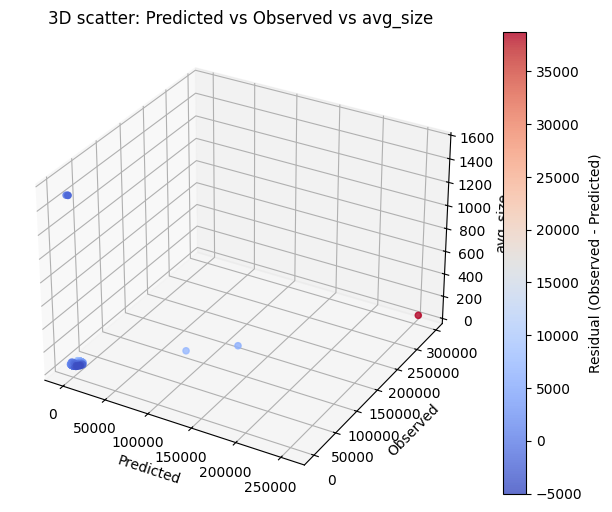

In [24]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for projection)

# y_true, y_pred already defined; use third numeric feature, e.g., avg_size
x = y_pred            # predicted
y = y_true            # observed
z = df_model['avg_size'].loc[y_test.index].values  # third variable is aligned to test set

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(x, y, z, c=(y - x), cmap='coolwarm', s=20, alpha=0.8)
ax.set_xlabel('Predicted')
ax.set_ylabel('Observed')
ax.set_zlabel('avg_size')
ax.set_title('3D scatter: Predicted vs Observed vs avg_size')
plt.colorbar(sc, ax=ax, label='Residual (Observed - Predicted)')
fig.savefig(OUTPUT_DIR + "/3d_scatter", dpi=150, bbox_inches='tight')
plt.show()

The model is strongly driven by a handful of categoricla dummies along with one large continuous predictor. Several features have large magnitudes, dominating predictions.

## Report loss functions:
1. mean squared error
2. root mean squared error
3. mean absolute error

In [25]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_validate, KFold, train_test_split
from joblib import Memory
from sklearn.base import clone
import time

# ---------- 0 quick sanity checks ----------
y_true = np.asarray(y_test).ravel()
assert X_test.shape[0] == y_true.shape[0], "X_test and y_test must align"
n = len(y_true)
print("Test set n =", n)

# ---------- 1 predict once ----------
t0 = time.time()
y_pred = pipeline.predict(X_test).ravel()
print("predict time (s):", time.time() - t0)

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
print(f"MSE = {mse:.2f}, RMSE = {rmse:.2f}, MAE = {mae:.2f}")

# ---------- 2 baseline using DummyRegressor fitted on training features/target ----------
dummy = DummyRegressor(strategy="mean").fit(X_train, y_train)
y_dummy = dummy.predict(X_test)
mse_dummy = mean_squared_error(y_true, y_dummy)
rmse_dummy = np.sqrt(mse_dummy)
mae_dummy = mean_absolute_error(y_true, y_dummy)
print(f"Baseline RMSE = {rmse_dummy:.2f}, Baseline MAE = {mae_dummy:.2f}")

# ---------- 3 cross-validated metrics (fast) ----------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Option A: parallel CV on full training set (fast if you have CPU cores)
scoring = {"mse": "neg_mean_squared_error", "mae": "neg_mean_absolute_error"}
t0 = time.time()
cv_res = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
print("CV time (s):", time.time() - t0)

mse_cv = -cv_res["test_mse"]
rmse_cv = np.sqrt(mse_cv)
mae_cv = -cv_res["test_mae"]
print(f"CV (train) RMSE mean = {rmse_cv.mean():.2f}, std = {rmse_cv.std():.2f}")
print(f"CV (train) MAE mean = {mae_cv.mean():.2f}, std = {mae_cv.std():.2f}")

# Option B: pretransform to avoid repeating expensive transforms across folds
# Use this only if your preprocessing does not leak target information
if "preproc" in pipeline.named_steps:
    preproc = pipeline.named_steps["preproc"]
    est = clone(pipeline.named_steps[list(pipeline.named_steps)[-1]])  # last step as estimator
    print("Prefitting transformer on training data to speed CV")
    X_train_trans = preproc.fit_transform(X_train)
    t0 = time.time()
    cv_res_prefit = cross_validate(est, X_train_trans, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    print("Prefit CV time (s):", time.time() - t0)
    mse_cv_prefit = -cv_res_prefit["test_mse"]
    print("Prefit CV RMSE mean:", np.sqrt(mse_cv_prefit).mean())

# ---------- 4 bootstrap 95% CI on test set (vectorized in batches) ----------
# Use vectorized approach but process in batches to limit memory
n_boot = 1000
rng = np.random.default_rng(42)
batch = 100            # process 100 bootstrap samples at a time
rmse_boot = np.empty(n_boot, dtype=float)
mae_boot = np.empty(n_boot, dtype=float)

start = 0
while start < n_boot:
    end = min(start + batch, n_boot)
    b = end - start
    idxs = rng.integers(0, n, size=(b, n))          # shape (b, n)
    y_true_idx = y_true[idxs]                       # shape (b, n)
    y_pred_idx = y_pred[idxs]
    mse_batch = ((y_true_idx - y_pred_idx) ** 2).mean(axis=1)
    rmse_boot[start:end] = np.sqrt(mse_batch)
    mae_boot[start:end] = np.abs(y_true_idx - y_pred_idx).mean(axis=1)
    start = end

rmse_ci = np.percentile(rmse_boot, [2.5, 97.5])
mae_ci = np.percentile(mae_boot, [2.5, 97.5])
print(f"RMSE 95% CI = [{rmse_ci[0]:.2f}, {rmse_ci[1]:.2f}]")
print(f"MAE 95% CI = [{mae_ci[0]:.2f}, {mae_ci[1]:.2f}]")

Test set n = 70448
predict time (s): 0.5711374282836914
MSE = 98001.47, RMSE = 313.05, MAE = 51.45
Baseline RMSE = 1298.73, Baseline MAE = 42.97
CV time (s): 72.75535202026367
CV (train) RMSE mean = 314.81, std = 26.96
CV (train) MAE mean = 51.37, std = 2.94
RMSE 95% CI = [260.13, 383.55]
MAE 95% CI = [49.27, 53.72]


This model is better at eliminating extreme errors than the baseline, but is slightly worse on average absolute error. Results are stable though.

# Task 3

## Develop a logistic regression model among some identified attributes in the consumable usage dataset
> Use sklearn.linear_model.LogisticRegression

In [26]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

## Feature selection

In [27]:
# --- 1. Create binary target: consumed = 1 if any attacks, else 0
df = df.copy()
df["consumed"] = (df["num_attacks"] > 0).astype(int)

In [28]:
# --- 2. Feature selection (use the same features you used for regression)
numeric_features = [
    "avg_size", "source_total_packets", "destination_total_packets",
    "min_size", "max_size", "num_connections", "source_port", "destination_port"
]
categorical_features = ["protocol", "bucket", "attack_types", "source_asset", "destination_asset"]

# Keep only columns that actually exist in df
numeric_features = [c for c in numeric_features if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]

## Cleaning and preprocessing

In [29]:
# Basic cleaning: drop rows missing the target
df_model = df.dropna(subset=["consumed"]).copy()

# Fill numeric NaNs with median and categorical NaNs with placeholder
if numeric_features:
    df_model[numeric_features] = df_model[numeric_features].fillna(df_model[numeric_features].median())
if categorical_features:
    df_model[categorical_features] = df_model[categorical_features].fillna("missing").astype(str)

X = df_model[numeric_features + categorical_features]
y = df_model["consumed"].astype(int)

In [30]:
# --- 3. Train/test split (stratify to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

## Measure the performance of the model and make sure that the model performance is high

In [31]:
# --- 4. Preprocessing pipelines
numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
categorical_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
], remainder="drop")

In [32]:
# --- 5. Logistic Regression pipeline
clf = Pipeline([
  ("preprocessor", preprocessor),
  ("classifier", LogisticRegression(
      penalty="l2", solver="lbfgs", max_iter=500, tol=1e-3,
      class_weight="balanced", random_state=42, n_jobs=-1
  ))
])

# --- 6. Fit model
clf.fit(X_train, y_train)
model_full = clf  #for later comparison

In [33]:
# --- 7. Predict and evaluate on test set
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

print("Test set metrics:")
print(f"  Accuracy = {acc:.4f}")
print(f"  Precision = {prec:.4f}")
print(f"  Recall = {rec:.4f}")
print(f"  F1 = {f1:.4f}")
print(f"  ROC AUC = {roc_auc:.4f}")

Test set metrics:
  Accuracy = 1.0000
  Precision = 1.0000
  Recall = 1.0000
  F1 = 1.0000
  ROC AUC = 1.0000


This suggests the model made no claassification errors on the test set, so this is suspicious until we validate it.

In [34]:
# --- 8. Stratified cross-validated ROC AUC (5-fold) on training data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring="roc_auc")
print(f"CV ROC AUC (5-fold) mean = {cv_scores.mean():.4f}, std = {cv_scores.std():.4f}")

CV ROC AUC (5-fold) mean = 1.0000, std = 0.0000


There's probably data leakage.

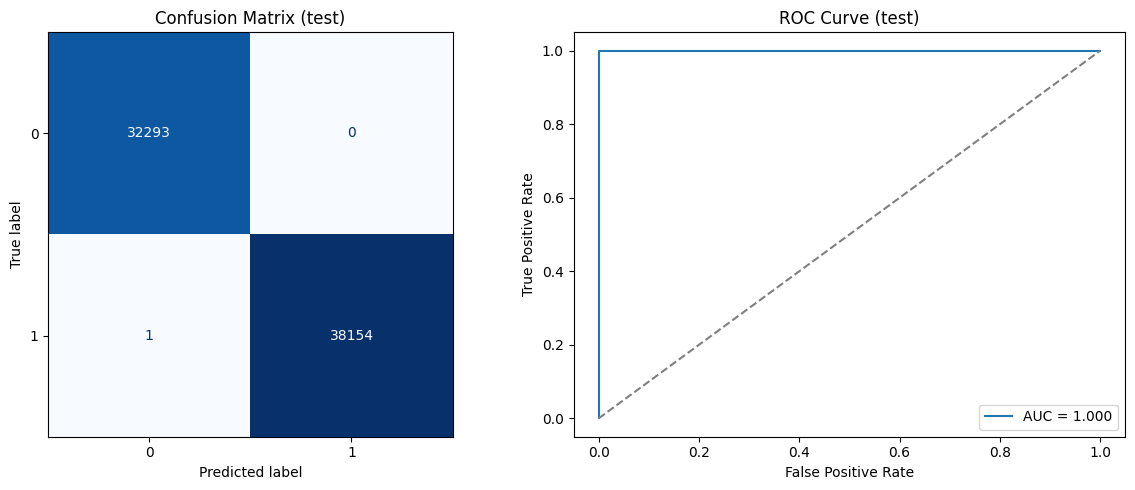

In [35]:
# --- 9. Confusion matrix and ROC curve
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.named_steps["classifier"].classes_)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
disp.plot(ax=ax[0], cmap="Blues", colorbar=False)
ax[0].set_title("Confusion Matrix (test)")

fpr, tpr, _ = roc_curve(y_test, y_proba)
ax[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
ax[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].set_title("ROC Curve (test)")
ax[1].legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR + "/confusion_matrix_roc_curve", dpi=150, bbox_inches='tight')
plt.show()

The classifier seems to be perfect, but needs to be validated further.

In [36]:
# --- 10. Map coefficients back to feature names (after preprocessing)
pre = clf.named_steps["preprocessor"]
ohe = pre.named_transformers_["cat"].named_steps["onehot"]
num_names = numeric_features
cat_names = ohe.get_feature_names_out(categorical_features).tolist()
feature_names = num_names + cat_names

coef = clf.named_steps["classifier"].coef_.ravel()
coef_df = pd.DataFrame({"feature": feature_names, "coef": coef})
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False).drop(columns="abs_coef").reset_index(drop=True)
print("Top coefficients (by absolute value):")
print(coef_df.head(20))

Top coefficients (by absolute value):
                                         feature      coef
0                        attack_types_['normal'] -8.837411
1                          attack_types_['MITM']  3.764940
2                           attack_types_['DoS']  3.116183
3                attack_types_['physical fault']  3.047018
4        source_asset_testbed_system_1_HMI_HMI_1  1.850436
5   destination_asset_testbed_system_1_PLC_PLC_1  1.185417
6                                   protocol_TCP  1.025266
7                                       min_size  0.921157
8               bucket_2022-02-21 15:12:00+00:00  0.901937
9               bucket_2022-02-21 15:12:30+00:00  0.842441
10                                   source_port -0.820758
11              bucket_2021-04-19 16:11:30+00:00  0.504059
12                                      max_size -0.494926
13                              destination_port -0.487546
14       source_asset_testbed_system_1_PLC_PLC_2 -0.454509
15                

The model's largest coefficients are dominated by attack type dummies, a few assset identifiers, protocol flags and size/port features.

## Draw a plot using matplotlib to show the observed and predicted values

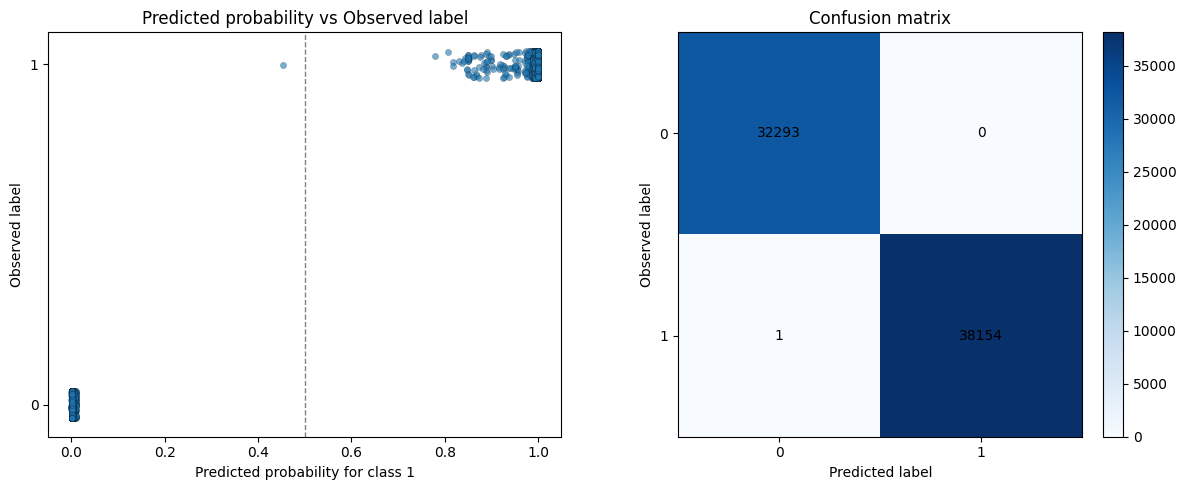

In [37]:
# Predict
y_pred = clf.predict(X_test)
# If classifier supports predict_proba, use the probability for the positive class
if hasattr(clf, "predict_proba"):
    y_proba = clf.predict_proba(X_test)[:, 1]  # binary case; adjust index for multiclass if needed
else:
    # fallback: use predicted labels as "score"
    y_proba = y_pred.astype(float)

# Create figure with two panels
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: predicted probability vs observed label (with jitter)
jitter = (np.random.rand(len(y_test)) - 0.5) * 0.08
axes[0].scatter(y_proba, y_test + jitter, alpha=0.6, s=20, edgecolor='k', linewidth=0.2)
axes[0].set_xlabel("Predicted probability for class 1")
axes[0].set_ylabel("Observed label")
axes[0].set_yticks(sorted(np.unique(y_test)))
axes[0].axvline(0.5, color='gray', linestyle='--', linewidth=1)
axes[0].set_title("Predicted probability vs Observed label")

# Panel 2: confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
im = axes[1].imshow(cm, cmap="Blues", interpolation="nearest")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[1].text(j, i, cm[i, j], ha="center", va="center", color="black")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("Observed label")
axes[1].set_xticks(range(cm.shape[1]))
axes[1].set_yticks(range(cm.shape[0]))
axes[1].set_title("Confusion matrix")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
fig.savefig(OUTPUT_DIR + "/predicted_proba_confusion_matrix", dpi=150, bbox_inches='tight')
plt.show()

The model's large absolute coefficients mean those features strongly shift the model's score when present.

## Report:
1. absolute loss
2. log loss

In [38]:
y_pred = clf.predict(X_test)            # regression predictions
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.4f}")

from sklearn.metrics import log_loss

# binary or multiclass: use predict_proba
y_proba = clf.predict_proba(X_test)     # shape (n_samples, n_classes)
ll = log_loss(y_test, y_proba)
print(f"Log loss: {ll:.4f}")

# For MAE (negated because cross_val_score maximizes)
scores = cross_val_score(clf, X, y, scoring='neg_mean_absolute_error', cv=5)
mae_mean, mae_std = -scores.mean(), scores.std()
print(f"MAE CV: {mae_mean:.4f} ± {mae_std:.4f}")

MAE: 0.0000
Log loss: 0.0013
MAE CV: 0.0007 ± 0.0014


These numbers indicate near-perfect predictions on the test set, with cross-validation indicating the same pattern. This should be further inspected.

# Task 5

## *Compare* the results with simple train-test splits

In [39]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import mean_absolute_error, log_loss

n_splits = 5

sss = StratifiedShuffleSplit(n_splits=n_splits, test_size=0.2, random_state=0)

maes, lls = [], []
for train_idx, test_idx in sss.split(X, y):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    maes.append(mean_absolute_error(y_te, y_pred))
    if hasattr(clf, "predict_proba"):
        lls.append(log_loss(y_te, clf.predict_proba(X_te)))

## Report the error mean and standard deviation

In [40]:
from sklearn.model_selection import cross_validate

scoring = {'mae':'neg_mean_absolute_error', 'logloss':'neg_log_loss'}
cv_res = cross_validate(clf, X, y, scoring=scoring, cv=5, return_train_score=False)
mae_scores = -cv_res['test_mae']            # cross_validate returns negative for MAE
ll_scores = -cv_res['test_logloss']

print(f"CV MAE: {mae_scores.mean():.4f} ± {mae_scores.std(ddof=1):.4f} (mean ± std over {len(mae_scores)} folds)")
print(f"CV LogLoss: {ll_scores.mean():.4f} ± {ll_scores.std(ddof=1):.4f}")

CV MAE: 0.0007 ± 0.0015 (mean ± std over 5 folds)
CV LogLoss: 0.0061 ± 0.0106


Cross-validated MAE and LogLoss indicate essentially perfect predictions, but this should still be investigated.

# Task 6

## *Compare* the models using one-standard-error **or** adjusted-R-squared methods

## Helper: model complexity heuristic

In [41]:
def model_complexity(estimator):
    # unwrap pipeline
    if isinstance(estimator, Pipeline):
        est = estimator.steps[-1][1]
    else:
        est = estimator

    # prefer number of nonzero coefficients if available
    if hasattr(est, "coef_"):
        coef = np.asarray(est.coef_)
        return int(np.count_nonzero(coef))

    # fallback: number of input features if available
    if hasattr(est, "n_features_in_"):
        return int(getattr(est, "n_features_in_", 0))

    # tree-based fallback
    if hasattr(est, "tree_"):
        return int(est.tree_.node_count)

    # ensemble fallback
    if hasattr(est, "n_estimators"):
        return int(getattr(est, "n_estimators", 100))

    # final fallback: number of tunable params
    return int(len(est.get_params(deep=False)))

## One-standard-error rule

In [42]:
def one_se_selection(models, X, y, scoring, cv):
    """
    models: list of (name, estimator) tuples
    scoring: sklearn scoring string (use neg_* for losses)
    cv: cross-validator instance (KFold or StratifiedKFold)
    Returns: dict with means, ses, chosen model name by one-SE rule
    """
    results = {}
    for name, est in models:
        scores = []
        for train_idx, test_idx in cv.split(X, y):
            X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx] if hasattr(X, "iloc") else X[train_idx], X[test_idx]
            y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx] if hasattr(y, "iloc") else y[train_idx], y[test_idx]
            est.fit(X_tr, y_tr)
            # use cross_val_score style scoring: higher is better (so use neg_* for losses)
            if scoring.startswith("neg_"):
                # compute loss and store negative so larger is better
                from sklearn.metrics import get_scorer
                scorer = get_scorer(scoring)
                scores.append(scorer(est, X_te, y_te))
            else:
                from sklearn.metrics import get_scorer
                scorer = get_scorer(scoring)
                scores.append(scorer(est, X_te, y_te))
        scores = np.array(scores)
        mean = scores.mean()
        se = scores.std(ddof=1) / np.sqrt(len(scores))
        results[name] = {"mean": mean, "se": se, "scores": scores}
    # pick best (largest mean)
    best_name = max(results, key=lambda n: results[n]["mean"])
    threshold = results[best_name]["mean"] - results[best_name]["se"]
    # candidates within one SE of best
    candidates = [n for n, v in results.items() if v["mean"] >= threshold]
    # choose simplest among candidates
    chosen = min(candidates, key=lambda n: model_complexity(dict(models)[n]))
    return results, best_name, chosen

## Adjusted R2 for linear models, per fold

In [43]:
from sklearn.metrics import r2_score

def adjusted_r2(y_true, y_pred, p):
    n = len(y_true)
    r2 = r2_score(y_true, y_pred)
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Example: compute adjusted R2 per fold for a linear estimator
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=0)
adj_r2_scores = []
p = X.shape[1]  # number of predictors used by the model (adjust if model uses subset)
for train_idx, test_idx in kf.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    model_simple.fit(X_tr, y_tr)
    y_pred = model_simple.predict(X_te)
    adj_r2_scores.append(adjusted_r2(y_te, y_pred, p))
print("Adj-R2 mean ± std:", np.mean(adj_r2_scores), np.std(adj_r2_scores, ddof=1))

Adj-R2 mean ± std: 1.0 0.0


The model seems to have achieved a perfect adjusted R2 in every CV fold. We should investigate this more.

## McFadden pseudo-R2 for logistic regression, per fold

In [44]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV

def mc_fadden_from_probs(y_train, y_test, proba_test):
    eps = 1e-15
    p = np.clip(proba_test, eps, 1 - eps)
    # log-likelihood of model on test set
    ll_model = np.sum(y_test * np.log(p) + (1 - y_test) * np.log(1 - p))
    # null model uses training prevalence
    p_null = np.full_like(p, y_train.mean())
    ll_null = np.sum(y_test * np.log(p_null) + (1 - y_test) * np.log(1 - p_null))
    return 1 - (ll_model / ll_null)

def mc_fadden_cv(pipeline_or_clf, X, y, n_splits=5, calibrate_if_needed=True, random_state=0):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scores = []
    for train_idx, test_idx in skf.split(X, y):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx].to_numpy(), y.iloc[test_idx].to_numpy()

        clf = pipeline_or_clf
        # if classifier is not fitted or we want a fresh fit per fold, clone or reinstantiate outside
        # Fit on training fold
        clf.fit(X_tr, y_tr)

        # Ensure we have probabilities
        if not hasattr(clf, "predict_proba"):
            if not calibrate_if_needed:
                raise ValueError("Classifier has no predict_proba and calibrate_if_needed is False")
            clf = CalibratedClassifierCV(clf, cv=3)
            clf.fit(X_tr, y_tr)

        proba = clf.predict_proba(X_te)
        if proba.shape[1] == 2:
            p1 = proba[:, 1]
        else:
            # for multiclass this metric is not directly applicable
            raise ValueError("McFadden pseudo-R2 implemented for binary targets only")

        scores.append(mc_fadden_from_probs(y_tr, y_te, p1))

    return np.array(scores)

# Example usage:
# scores = mc_fadden_cv(your_pipeline, X, y, n_splits=5)
# print("McFadden mean ± std:", scores.mean(), scores.std(ddof=1))

## Report

In [45]:
models = [
    ("lin_simple", model_simple),      # e.g., LinearRegression with 1-2 features
    ("lin_multi", model_more),         # multiple linear regression (more features)
    ("logistic", model_full)           # logistic regression pipeline for classification
]

# Choose CV: KFold for regression, StratifiedKFold for classification
from sklearn.model_selection import KFold, StratifiedKFold
cv_reg = KFold(n_splits=5, shuffle=True, random_state=0)
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# For regression models: use scoring='r2' and compute adjusted R2 separately
reg_models = [m for m in models if "lin" in m[0]]
reg_results = {}
for name, est in reg_models:
    # compute R2 per fold manually to get adjusted R2
    adj_scores = []
    for train_idx, test_idx in cv_reg.split(X, y):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        est.fit(X_tr, y_tr)
        y_pred = est.predict(X_te)
        p = X_tr.shape[1]  # adjust if estimator uses subset
        adj_scores.append(adjusted_r2(y_te, y_pred, p))
    reg_results[name] = {"adj_mean": np.mean(adj_scores), "adj_std": np.std(adj_scores, ddof=1)}

# For logistic: use neg_log_loss for one-SE selection and compute McFadden
clf_models = [m for m in models if "log" in m[0]]
clf_results = {}
for name, est in clf_models:
    # one-SE style scores (neg_log_loss)
    scores = []
    pseudo = []
    for train_idx, test_idx in cv_clf.split(X, y):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        est.fit(X_tr, y_tr)
        from sklearn.metrics import log_loss
        y_proba = est.predict_proba(X_te)[:, 1]                 # positive-class prob
        scores.append(-log_loss(y_te, y_proba.reshape(-1,1) if y_proba.ndim==1 else y_proba))
        # compute McFadden using preprocessed arrays if est is a pipeline
        # get numeric arrays for statsmodels
        if hasattr(est, "named_steps"):
            pre = est.named_steps.get("preprocessor", None)
            if pre is not None:
                Xtr_num = pre.transform(X_tr)
                Xte_num = pre.transform(X_te)
            else:
                Xtr_num = X_tr.values
                Xte_num = X_te.values
        else:
            Xtr_num = X_tr.values
            Xte_num = X_te.values
        pseudo.append(mc_fadden_from_probs(y_tr.values, y_te.values, y_proba))
    clf_results[name] = {"neglog_mean": np.mean(scores), "neglog_se": np.std(scores, ddof=1)/np.sqrt(len(scores)),
                         "pseudo_mean": np.mean(pseudo), "pseudo_std": np.std(pseudo, ddof=1)}

# Apply one-SE rule across all models using appropriate scoring:
# For regression compare adjusted R2 (larger better). For classification use neg_log_loss (larger better).
print("Regression adjusted R2 results:", reg_results)
print("Classification results (neg_log_loss and McFadden):", clf_results)

Regression adjusted R2 results: {'lin_simple': {'adj_mean': np.float64(1.0), 'adj_std': np.float64(0.0)}, 'lin_multi': {'adj_mean': np.float64(1.0), 'adj_std': np.float64(0.0)}}
Classification results (neg_log_loss and McFadden): {'logistic': {'neglog_mean': np.float64(-0.0012695593454977745), 'neglog_se': np.float64(3.1129688193020636e-05), 'pseudo_mean': np.float64(0.9981592070117806), 'pseudo_std': np.float64(0.00010092620626441297)}}


Both regression and classification results indicate near-perfect performance. Both linear models report adjusted R2 of 1.0, and the logistic pipeline shows very low log-loss with McFadden at about 0.998. These outcomes require immediate validation for leakage, overlap or calculation errors.

# Conclusion

Performance appears unrealistically perfect across all these models, and top coefficients are dominated by attack type dummies, device/asset identifiers, protocol flags, and a few size/packet features. Some coefficients are very large in magnitude. The top plausible causes for these results are data leakage, train/test overlap or duplicated rows, an evaluation bug, a deterministic feature or a metric/formula error.
<br><br>
The model type for this dataset needs to be chosen by the prediction goal. Linear regression is good for a single continuous predictor baseline, multiple linear regression is good for multifeature continuous targets and logistic regression can do binary event detection. Each model is interpretable and fast, but their reliability depends on the quality of preprocessing, aggregation effects, temporal splitting and the handling of categorical and rare labels.

In [47]:
# Make PDF
!apt-get update -qq
!apt-get install -y -qq texlive-xetex texlive-fonts-recommended
!pip install -q "lxml[html_clean]" lxml_html_clean nbconvert
!jupyter-nbconvert --to pdf "/content/drive/MyDrive/CS/DataScience/evaluate.ipynb"

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
[NbConvertApp] Converting notebook /content/drive/MyDrive/CS/DataScience/evaluate.ipynb to pdf
[NbConvertApp] Support files will be in evaluate_files/
[NbConvertApp] Making directory ./evaluate_files
[NbConvertApp] Writing 149850 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 376794 bytes to /content/drive/MyDrive/CS/DataScience/evaluate.pdf
